In [ ]:
# ============================================================
# PARTE 2: Regresión Lineal — Peso vs Estatura (Variables Invertidas)
# En esta sección se invierte el análisis original:
#   Variable Independiente (X) = Peso (KG)
#   Variable Dependiente   (Y) = Altura (cm)
# ============================================================

# Importación de librerías necesarias
from google.colab import auth       # Para autenticación en Google Colab
import gspread                       # Para acceder a Google Sheets
from google.auth import default      # Para obtener credenciales por defecto
import pandas as pd                  # Para manejo de datos en tablas (DataFrames)
import numpy as np                   # Para operaciones matemáticas y vectoriales
import matplotlib.pyplot as plt      # Para crear gráficas

# Autenticación del usuario en Google
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# Apertura del archivo de Google Sheets mediante su ID único
file_id = '11vJXajjCLX1-LJeQ3FXsCo_yr-zZv49mnHq-6MDlhqw'
sh = gc.open_by_key(file_id)

# Acceso a la hoja de cálculo específica llamada '5A'
worksheet = sh.worksheet('5A')

# Lectura del rango de datos A1:E23 (encabezado + 22 registros de alumnos)
datos = worksheet.get('A1:E23')

# Conversión de los datos a un DataFrame de pandas
# La primera fila se usa como encabezado de columnas
df = pd.DataFrame(datos[1:], columns=datos[0])

# Visualización de las primeras filas para verificar la carga de datos
print(df.head())

  No.  Matrícula           Nombre del Estudiante Altura (cm) Peso (KG)
0   1  243112024         ARTEAGA CASTILLO ISRAEL         189       104
1   2  243110670     AVILA ENCISO GUILLERMO JOSE         176        90
2   3  243111514         AVILA JUAREZ JOSE ANGEL         182       110
3   4  243110528           AVILA VAZQUEZ ARMANDO         172        87
4   5  243111280  CERON TRUJILLO XAVIER APOLINAR         170        63


In [ ]:
# ============================================================
# CÁLCULO DEL COEFICIENTE DE CORRELACIÓN (r)
# Fórmula de Pearson:
#   r = (n·Σxy - Σx·Σy) / sqrt[(n·Σx² - (Σx)²) · (n·Σy² - (Σy)²)]
#
# IMPORTANTE: Las variables están INVERTIDAS respecto al análisis original:
#   x = Peso (KG)   → variable independiente
#   y = Altura (cm) → variable dependiente
# ============================================================

# Extracción y conversión numérica de las columnas
# 'errors=coerce' convierte valores no numéricos en NaN (sin lanzar error)
x = pd.to_numeric(df['Peso (KG)'],   errors='coerce')   # X = Peso (variable independiente)
y = pd.to_numeric(df['Altura (cm)'], errors='coerce')   # Y = Altura (variable dependiente)

# Cálculo de las sumas necesarias para la fórmula de Pearson
n      = len(x)              # Número total de datos (alumnos)
sum_x  = x.sum()             # Σx: suma de todos los pesos
sum_y  = y.sum()             # Σy: suma de todas las alturas
sum_xy = (x * y).sum()       # Σxy: suma de productos peso×altura
sum_x2 = (x ** 2).sum()      # Σx²: suma de cuadrados de los pesos
sum_y2 = (y ** 2).sum()      # Σy²: suma de cuadrados de las alturas

# Aplicación de la fórmula del coeficiente de correlación de Pearson
r = (n * sum_xy - sum_x * sum_y) / \
    np.sqrt((n * sum_x2 - sum_x**2) * (n * sum_y2 - sum_y**2))

# Nota: El coeficiente r es SIMÉTRICO, por lo que su valor es
# idéntico al obtenido en el análisis original (Altura vs Peso).
# Solo cambian los coeficientes de la recta de regresión (m y b).
print(f"Coeficiente de correlación r = {r:.4f}")

Coeficiente de correlación r = 0.8182


In [ ]:
# ============================================================
# ESTADÍSTICAS DESCRIPTIVAS DE LAS VARIABLES
# Se calculan la media y desviación estándar de cada variable
# para describir la distribución de los datos.
# ============================================================

# Media aritmética de cada variable
media_x = x.mean()   # Promedio del Peso (KG)
media_y = y.mean()   # Promedio de la Altura (cm)

# Desviación estándar (mide la dispersión de los datos respecto a su media)
std_x = x.std()      # Desviación estándar del Peso
std_y = y.std()      # Desviación estándar de la Altura

# Impresión de resultados
print(f"Media X (Peso):      {media_x:.4f} kg")
print(f"Media Y (Altura):    {media_y:.4f} cm")
print(f"Desv. Est. X (Peso): {std_x:.4f}")
print(f"Desv. Est. Y (Alt.): {std_y:.4f}")

Media X (Peso):      70.1364 kg
Media Y (Altura):    169.1364 cm
Desv. Est. X (Peso): 18.9819
Desv. Est. Y (Alt.): 8.3226


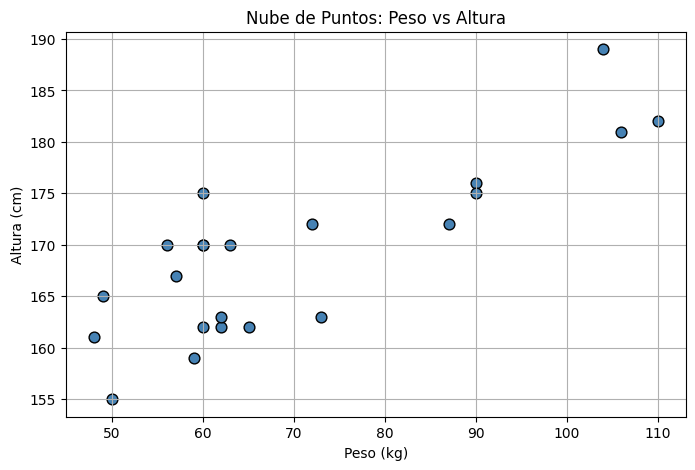

In [ ]:
# ============================================================
# GRÁFICA 1: NUBE DE PUNTOS (Diagrama de dispersión)
# Visualiza la relación entre Peso (X) y Altura (Y).
# Cada punto representa un alumno del grupo 5A.
# ============================================================

# Creación de la figura con tamaño 8×5 pulgadas
plt.figure(figsize=(8, 5))

# Gráfica de dispersión:
#   color='steelblue' → color de relleno de los puntos
#   edgecolors='black' → borde negro en cada punto
#   s=60 → tamaño de los puntos
plt.scatter(x, y, color='steelblue', edgecolors='black', s=60)

# Etiquetas de los ejes (invertidas respecto al análisis original)
plt.xlabel('Peso (kg)')    # Eje horizontal: Peso
plt.ylabel('Altura (cm)')  # Eje vertical: Altura

# Título descriptivo de la gráfica
plt.title('Nube de Puntos: Peso vs Altura')

# Activar cuadrícula para facilitar la lectura
plt.grid(True)

# Mostrar la gráfica
plt.show()

In [ ]:
# ============================================================
# CÁLCULO DE LOS COEFICIENTES DE LA RECTA DE REGRESIÓN
# Ecuación de la recta: y = m·x + b
#
# Pendiente (m):
#   m = (n·Σxy - Σx·Σy) / (n·Σx² - (Σx)²)
#
# Intercepto (b):
#   b = (Σy - m·Σx) / n
#
# Con variables INVERTIDAS:
#   m = variación de Altura por cada kg adicional de Peso
#   b = Altura estimada cuando el Peso es 0 (valor teórico)
# ============================================================

# Cálculo de la pendiente de la recta de regresión
m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)

# Cálculo del intercepto con el eje Y
b = (sum_y - m * sum_x) / n

# Impresión de los parámetros de la recta
print(f"Pendiente  m = {m:.4f}")
print(f"Intercepto b = {b:.4f}")
print(f"Recta: y = {m:.4f}x + ({b:.4f})")
print("  → Interpretación: por cada kg adicional de peso,")
print(f"    la altura estimada varía {m:.4f} cm")

Pendiente  m = 0.3588
Intercepto b = 143.9742
Recta: y = 0.3588x + (143.9742)
  → Interpretación: por cada kg adicional de peso,
    la altura estimada varía 0.3588 cm


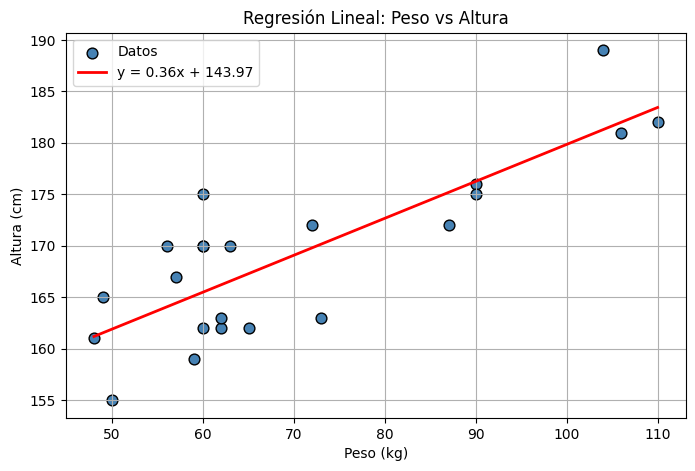

In [ ]:
# ============================================================
# GRÁFICA 2: NUBE DE PUNTOS + RECTA DE REGRESIÓN
# Se superpone la recta calculada sobre el diagrama de dispersión
# para visualizar el ajuste lineal.
# ============================================================

# Generación de 100 valores de X para dibujar la recta suavemente
# (desde el peso mínimo hasta el peso máximo del conjunto de datos)
x_linea = np.linspace(x.min(), x.max(), 100)

# Cálculo de los valores Y correspondientes usando la ecuación de la recta
y_linea = m * x_linea + b

# Creación de la figura con tamaño 8×5 pulgadas
plt.figure(figsize=(8, 5))

# Diagrama de dispersión (datos reales)
plt.scatter(x, y, color='steelblue', edgecolors='black', s=60, label='Datos')

# Recta de regresión (en rojo, grosor 2)
# La etiqueta muestra la ecuación de la recta con 2 decimales
plt.plot(x_linea, y_linea, color='red', linewidth=2,
         label=f'y = {m:.2f}x + {b:.2f}')

# Etiquetas de los ejes
plt.xlabel('Peso (kg)')    # Eje X: variable independiente
plt.ylabel('Altura (cm)')  # Eje Y: variable dependiente

# Título descriptivo
plt.title('Regresión Lineal: Peso vs Altura')

# Leyenda, cuadrícula y visualización
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# PREDICCIÓN: Altura estimada para un peso dado
# Se aplica la ecuación de la recta: y = m·x + b
# para predecir la Altura a partir de un Peso específico.
# ============================================================

# Valor de peso para el cual se desea predecir la altura
peso_pred = 80   # En kilogramos (ajustar según el análisis deseado)

# Cálculo de la altura estimada mediante la ecuación de la recta
altura_pred = m * peso_pred + b

# Impresión del resultado
print(f"Para un peso de {peso_pred} kg:")
print(f"Altura estimada = {altura_pred:.2f} cm")

Para un peso de 80 kg:
Altura estimada = 172.68 cm


Pendiente  m = 0.3588
Intercepto b = 143.9742
Ecuación:  y = 0.3588x + (143.9742)
Coef. correlación r = 0.8182
Error estándar Se = 4.9026 cm


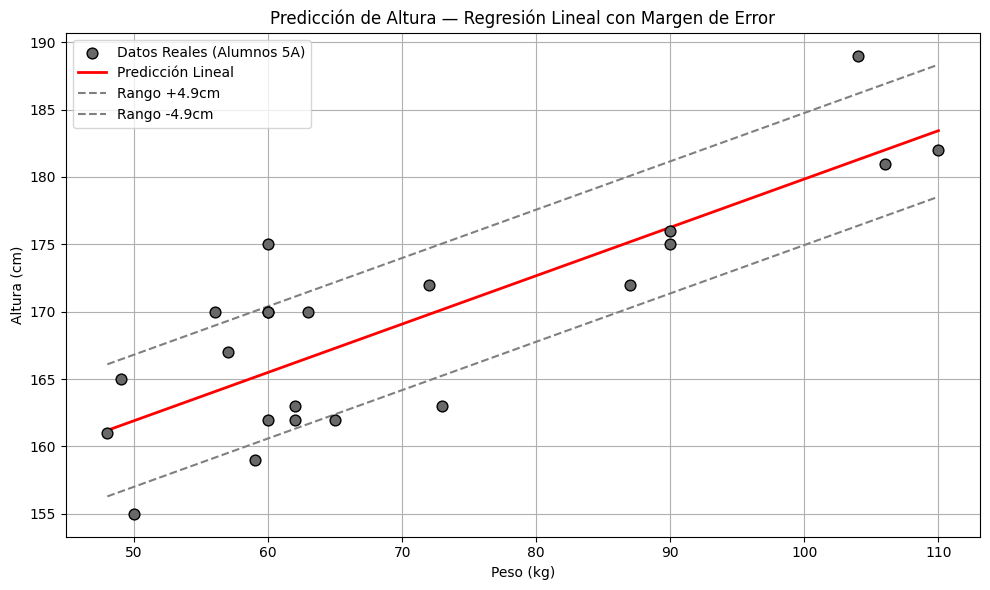

In [ ]:
# ============================================================
# GRÁFICA 3: REGRESIÓN LINEAL CON MÁRGENES DE ERROR
# Se calcula el Error Estándar de Estimación (Se) y se visualizan
# las bandas de confianza ±Se alrededor de la recta de regresión.
#
# Error Estándar de Estimación (Se):
#   Se = sqrt( Σ(y_real - y_estimado)² / (n - 2) )
# El divisor (n-2) corrige el sesgo al estimar 2 parámetros (m y b).
# ============================================================

# Importación del módulo stats de scipy (no se usa directamente,
# pero es útil para análisis estadísticos complementarios)
from scipy import stats

# Recalculamos m y b (por claridad y para que la celda sea autónoma)
m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
b = (sum_y - m * sum_x) / n

# Cálculo de los valores Y estimados por la recta para cada punto real
y_pred = m * x + b

# Cálculo del Error Estándar de Estimación (Se)
# Mide cuánto se desvían en promedio las alturas reales de las estimadas
Se = np.sqrt(((y - y_pred)**2).sum() / (n - 2))

# Resumen de resultados del análisis de regresión
print(f"Pendiente  m = {m:.4f}")
print(f"Intercepto b = {b:.4f}")
print(f"Ecuación:  y = {m:.4f}x + ({b:.4f})")
print(f"Coef. correlación r = {r:.4f}")
print(f"Error estándar Se = {Se:.4f} cm")

# Generación de puntos para dibujar la recta y sus márgenes
x_linea = np.linspace(x.min(), x.max(), 100)
y_linea = m * x_linea + b

# ---- GRÁFICA ----
plt.figure(figsize=(10, 6))

# Puntos de datos reales (alumnos del grupo 5A)
plt.scatter(x, y,
            color='dimgray', edgecolors='black', s=60,
            label='Datos Reales (Alumnos 5A)', zorder=5)

# Recta de regresión (predicción central)
plt.plot(x_linea, y_linea,
         color='red', linewidth=2, linestyle='-',
         label='Predicción Lineal')

# Banda superior: recta + Se (límite superior del margen de error)
plt.plot(x_linea, y_linea + Se,
         color='gray', linewidth=1.5, linestyle='--',
         label=f'Rango +{Se:.1f}cm')

# Banda inferior: recta - Se (límite inferior del margen de error)
plt.plot(x_linea, y_linea - Se,
         color='gray', linewidth=1.5, linestyle='--',
         label=f'Rango -{Se:.1f}cm')

# Etiquetas, título, leyenda y visualización
plt.xlabel('Peso (kg)')    # Eje X: variable independiente
plt.ylabel('Altura (cm)')  # Eje Y: variable dependiente
plt.title('Predicción de Altura — Regresión Lineal con Margen de Error')
plt.legend()
plt.grid(True)
plt.tight_layout()   # Ajuste automático de márgenes para mejor presentación
plt.show()